# House-Edge 🎰
### "Lever a good timing model and you'll beat the market." Will you, though — after the financing bill?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free leverage?: Busted](https://img.shields.io/badge/Free_leverage%3F-Busted-8b949e?style=flat-square)

Every leveraged-ETF and CFD timing product sells the same dream: take a clever strategy — buy the dips, dial risk up and down, sidestep the bear markets — pour leverage on it, and you beat buy-and-hold. Leverage just *amplifies* a good signal, right? We build exactly that strategy and run it on the S&P 500 back to 1990 — but we charge leverage what it **actually** costs (the whole position financed, every single day), not the flattering version the brochures use. The risk control turns out to be real. The market-beating turns out to be a mirage.

> 📓 **This is the plain-language layer.** The cost accounting, the financing sweep and the house-edge identity are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it; the core runs on a **synthetic** market, so the real S&P numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from house_edge import data, strategy, costs, extension

# Offline synthetic control: an equity index with GARCH vol-clustering + persistent bear regimes.
# The real S&P 500 verdict is in ../docs/results.md.
price, rate, truth = data.synthetic_market(seed=30)
e = strategy.exposure(price)
print(f"synthetic control: {truth.n_days} days, {truth.n_crashes} bear regimes, seed {truth.seed}")


synthetic control: 6048 days, 9 bear regimes, seed 30


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the risk management work? | ✅ **Yes.** The strategy **halves the worst drawdown** — **-27.8%** vs buy-and-hold's **-55.7%** on the real S&P. |
| Does the *levered* version beat buy-and-hold? | 🚫 **No.** Financed honestly it makes **5.3%** a year vs the index's **10.6%** — *half the return*, lower Sharpe. |
| Is leverage 'almost free' like the backtests imply? | ⚪ **Busted.** The optimistic accounting hides **1.55 pts/yr** of financing — the broker's house edge. |

> Desk shorthand: **Signal `REAL` · Tradability `MIRAGE` · Free leverage? `BUSTED`** — you can buy a smoother ride, but not, this way, a bigger one.

## 1 · The claim 📣

The strategy is a faithful steelman of what the timing-product sellers pitch, three good ideas stacked:

1. **Buy the dip** — lean *into* short-term weakness (a low 2-day RSI raises the target), the classic short-horizon reversal.
2. **Target volatility** — size to `target_vol / recent_vol`, so leverage gets *cut* when markets get wild instead of riding the crash down.
3. **Respect the trend** — go to cash below the 200-day average, so you're not holding a falling knife through a real bear.

Each piece is real and well-studied. The claim is that *assembled and levered*, the package beats just owning the index.

average exposure 0.70x  |  time fully in cash 29%


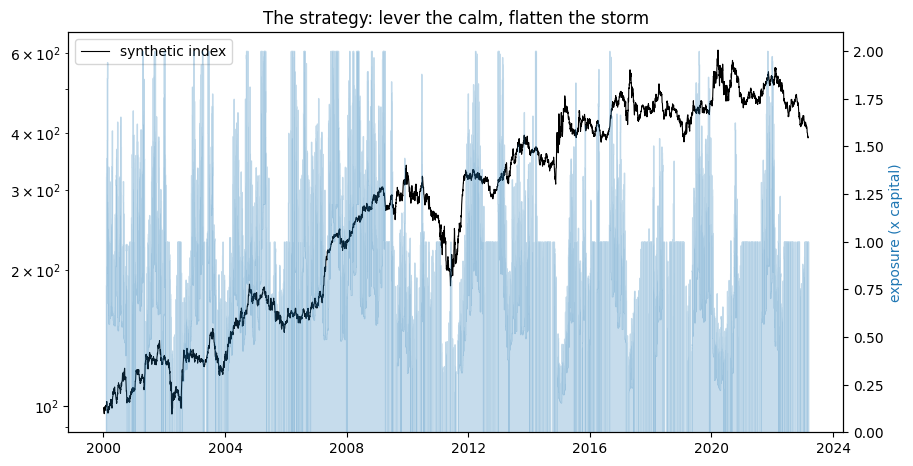

In [2]:
fig, ax = plt.subplots()
ax.plot(price.index, price.values, lw=0.8, color='black', label='synthetic index')
ax2 = ax.twinx()
ax2.fill_between(e.index, 0, e.values, color='#1f77b4', alpha=0.25, step='pre', label='target exposure')
ax2.set_ylabel('exposure (x capital)', color='#1f77b4'); ax2.set_ylim(0, 2.1)
ax.set_yscale('log'); ax.set_title('The strategy: lever the calm, flatten the storm'); ax.legend(loc='upper left')
print(f'average exposure {e.mean():.2f}x  |  time fully in cash {100*(e==0).mean():.0f}%')

## 2 · So what? 💰

If it worked, it would be the holy grail of retail trading: a rules-based way to beat the index *with the index*, just by sizing cleverly and borrowing. It's a multi-billion-dollar pitch — leveraged ETFs, CFD 'systems', vol-targeting overlays. The catch nobody puts on the slide is that leverage is *rented*, and the rent is charged on the **whole** position, every day. The desk's question: once you actually pay that rent, what's left?

## 3 · How we'd know 🔬

Two measurements, one trap:

1. **Does it cut risk?** Compare max-drawdown of the strategy vs buy-and-hold.
2. **Does it cut *return*?** Same comparison on CAGR and Sharpe — financed **honestly** (the whole notional, plus dividends, plus interest on idle cash).
3. **The trap:** the *idealized* accounting that finances only the bit above 100% and forgets dividends. The gap between the two is the house edge.

**Mirage line:** financed honestly, the levered book makes *less* than buy-and-hold — at every financing cost.

## 4 · The teardown 🔧

### 4a · The real part — it halves the drawdown

max drawdown  strategy -35%   vs   buy & hold -44%


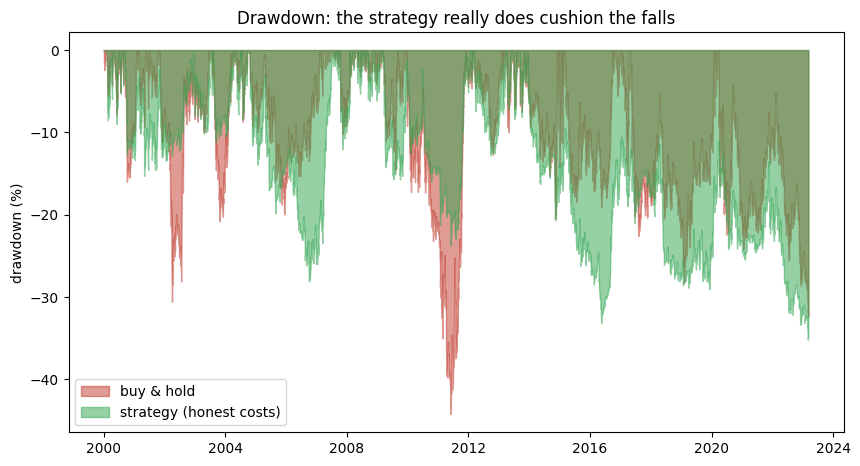

In [3]:
bh = costs.buy_and_hold(price)
hon = costs.net_returns(e, price, rate, mode='honest')
eq_bh = (1+bh).cumprod(); eq_s = (1+hon).cumprod()
dd_bh = eq_bh/eq_bh.cummax()-1; dd_s = eq_s/eq_s.cummax()-1
fig, ax = plt.subplots()
ax.fill_between(dd_bh.index, dd_bh*100, 0, color='#c0392b', alpha=0.5, label='buy & hold')
ax.fill_between(dd_s.index, dd_s*100, 0, color='#2ea44f', alpha=0.5, label='strategy (honest costs)')
ax.set_ylabel('drawdown (%)'); ax.set_title('Drawdown: the strategy really does cushion the falls'); ax.legend()
print(f"max drawdown  strategy {dd_s.min()*100:.0f}%   vs   buy & hold {dd_bh.min()*100:.0f}%")

On the real S&P 500 the gap is even starker: **-27.8%** vs **-55.7%** — the worst loss roughly halved (../docs/results.md). That part of the pitch is true.

### 4b · The mirage — and *less* return for it

In [4]:
ideal = costs.net_returns(e, price, rate, mode='idealized')
for nm, r in [('buy & hold (total return)', bh), ('strategy: IDEALIZED costs', ideal), ('strategy: HONEST costs', hon)]:
    s = strategy.summary(r)
    print(f"{nm:30} CAGR {s['cagr']*100:5.1f}%   Sharpe {s['sharpe']:5.2f}   maxDD {s['max_drawdown']*100:5.0f}%")
he = costs.house_edge(e, price, rate)
print(f"\nhouse edge (idealized - honest CAGR): {he['house_edge_ann']*100:.2f} pts/yr -- the financing the rosy accounting hides")

buy & hold (total return)      CAGR   7.8%   Sharpe  0.51   maxDD   -44%
strategy: IDEALIZED costs      CAGR   3.0%   Sharpe  0.29   maxDD   -33%
strategy: HONEST costs         CAGR   2.0%   Sharpe  0.22   maxDD   -35%

house edge (idealized - honest CAGR): 0.95 pts/yr -- the financing the rosy accounting hides


> 🔬 **For the quants.** The same exposure path, two cost models: *idealized* finances only the slice above 100% and ignores dividends; *honest* finances the whole notional at T-bill + 2.5%, credits dividends, pays interest on cash. On the real S&P that gap is **1.55 pts/yr** — and the honestly-financed book makes **5.3%** vs the index's **10.6%**.

## 5 · The verdict 🧾

- **Risk control is real** — drawdown roughly halved (-27.8% vs -55.7% on the S&P).
- **Return edge is a mirage** — financed honestly, 5.3%/yr vs buy-and-hold 10.6%/yr, at a *lower* Sharpe (0.42 vs 0.65).
- **'Free leverage' is busted** — 1.55 pts/yr of financing hidden by the optimistic accounting.

> **Signal `REAL` · Tradability `MIRAGE` · Free leverage? `BUSTED`.** The strategy and the plain index have the *same* Calmar (0.19) — per unit of drawdown survived, neither is ahead. You're buying insurance, not alpha.

## 6 · Could you trade it? 💸

- **You'd underperform the thing you're levering.** Half the return of just holding an S&P total-return ETF — which costs ~0.03%/yr and needs no skill.
- **The financing is unavoidable** — it's the cost of carry; a CFD/margin/futures position funds its whole notional. There's no version where the first 100% of leverage is free.
- **What it's genuinely *for*:** survival and leverage headroom. If a −56% buy-and-hold drawdown would liquidate you (or stop you sleeping), paying return for a −28% one can be worth it. That's risk management, not a market-beating edge — and it's the honest reason to run it.

## 7 · Going further 🚪

- **The financing sweep** (beat 7 of the quants notebook + [`../docs/results.md`](../docs/results.md)): the levered book trails buy-and-hold at *every* markup — even at a zero markup (pure T-bill funding), volatility drag alone keeps it behind. Not a tuning miss.
- **Where leverage *can* pay:** on assets with a real Sharpe above the index's, or as a small constant tilt (not a timing overlay). Test a levered *risk-parity* book vs this timing one.
- **The drawdown you're buying:** is the −28% worth the −5pts/yr of CAGR for *your* utility? That's a personal trade-off, not a universal verdict — fork the notebook and price it for your own risk aversion.

PRs welcome — add a levered constant-tilt benchmark, or a utility-based drawdown price.